In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import operator
import os

load_dotenv()

True

In [2]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [3]:
# state define

from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: ChatState):
    
    # take user query from state
    messages = state["messages"]
    
    # send to llm
    response = llm.invoke(messages)
    
    # store in state
    return {"messages": [response]}

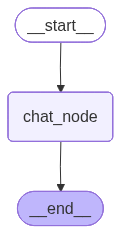

In [5]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [ ]:
# initial_state = {"messages": "What is the capital of Afghanistan?"}

# result = workflow.invoke(initial_state)

# human_message = result["messages"][0].content
# ai_message = result["messages"][1].content

# print(human_message)
# print(ai_message)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [7]:
thread_id = '1'

while True:
    user_message = input("Type here...")
    
    print("User: ", user_message)
    
    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break
    
    config = {"configurable": {"thread_id": thread_id}}
    
    response = workflow.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)
    
    print("AI: ", response["messages"][-1].content)

User:  My name is Ehsa
AI:  Hello Ehsa, it's nice to meet you. Is there something I can help you with or would you like to chat?
User:  What is my name?
AI:  Your name is Ehsa.
User:  what is the result of 100 and 1
AI:  The result of 100 + 1 is 101.
User:  add 4 with result
AI:  The result was 101. Adding 4 to that makes:

101 + 4 = 105
User:  exit


In [8]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='My name is Ehsa', additional_kwargs={}, response_metadata={}, id='d9178ba9-8dd6-44b2-887c-b47f8a70e223'), AIMessage(content="Hello Ehsa, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 41, 'total_tokens': 69, 'completion_time': 0.052539118, 'completion_tokens_details': None, 'prompt_time': 0.004730254, 'prompt_tokens_details': None, 'queue_time': 0.008426835, 'total_time': 0.057269372}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9f6-34f4-74b0-b986-dd3115f0a13a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 28, 'total_tokens': 69}), HumanMessage(content='What is my name?', additional_kwargs={},